<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [27]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

zsh:1: command not found: wget


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [ ]:
# !pip install pandas
# !pip install matplotlib
!pip install ipython-sql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [40]:
# Read the CSV file
df = pd.read_csv('/Users/michalbando/Downloads/Różne/IT/Python/data/survey_data2.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [30]:
import sqlite3
# import ipython-sql

%load_ext sql

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


The sql extension is already loaded. To reload it, use:
  %reload_ext sql


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [31]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')
%sql sqlite:///survey-data.sqlite
# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [ ]:
QUERY = """
SELECT COUNT(*)
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [ ]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [34]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [45]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'
%sql sqlite:///survey-data.sqlite

In [53]:
%%sql
SELECT ResponseId, MainBranch, Age, Employment FROM main limit 5;

 * sqlite:///survey-data.sqlite
Done.


ResponseId,MainBranch,Age,Employment
1,I am a developer by profession,Under 18 years old,"Employed, full-time"
2,I am a developer by profession,35-44 years old,"Employed, full-time"
3,I am a developer by profession,45-54 years old,"Employed, full-time"
4,I am learning to code,18-24 years old,"Student, full-time"
5,I am a developer by profession,18-24 years old,"Student, full-time"


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [ ]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"COUNT(*)" INTEGER
)


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [43]:
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)

<Axes: xlabel='CompTotal', ylabel='Count'>

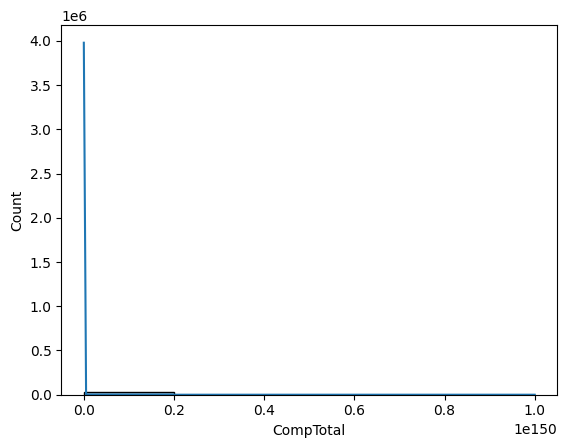

In [42]:
sns.histplot(data=df,x='CompTotal', bins=5, kde=True)

**Box Plots**

Plot a box plot of Age.


/var/folders/77/bxgbvz0s0r14k6cfkqvfpr9m0000gn/T/ipykernel_91836/1847356307.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Age', palette='viridis')


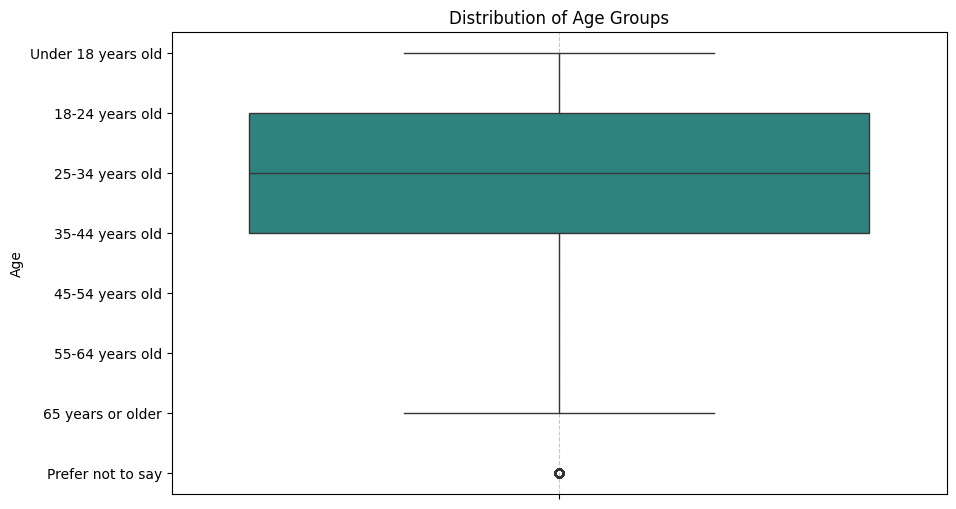

In [ ]:
# Definiujemy poprawną kolejność grup wiekowych
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old',
    '65 years or older', 'Prefer not to say'
]

# Konwertujemy kolumnę na typ kategoryczny z określoną kolejnością
df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)

plt.figure(figsize=(10, 6))

# Ustawiamy 'Age' na osi y zamiast x
sns.boxplot(data=df, y='Age', palette='viridis')

plt.title('Distribution of Age Groups')
plt.grid(axis='x', linestyle='--', alpha=0.7) # Dodaje pomocniczą siatkę
plt.show()

/var/folders/77/bxgbvz0s0r14k6cfkqvfpr9m0000gn/T/ipykernel_91836/908104980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Age', order=age_order, palette='magma')


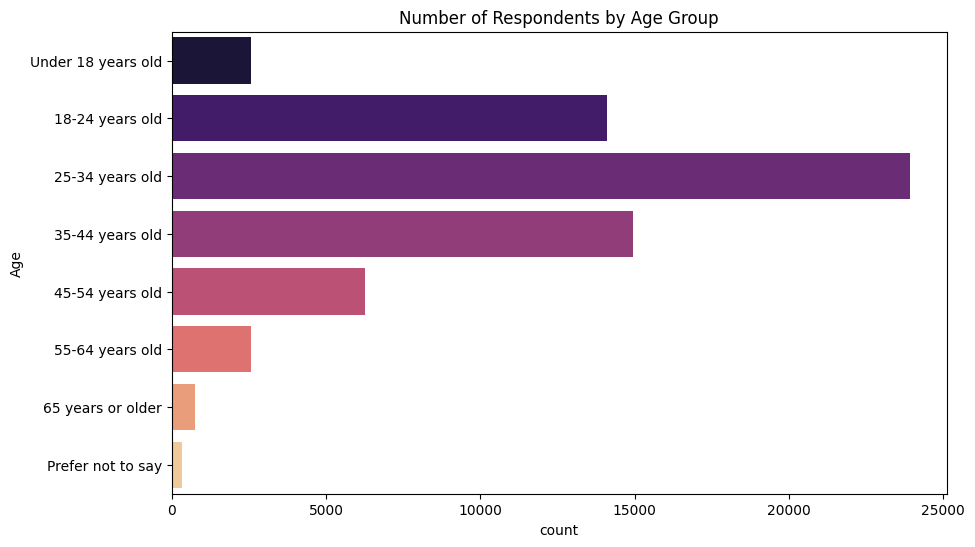

In [63]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Age', order=age_order, palette='magma')
plt.title('Number of Respondents by Age Group')
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


<Axes: xlabel='Age', ylabel='WorkExp'>

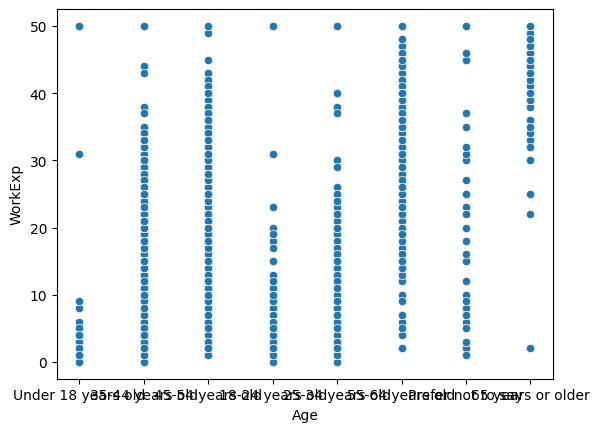

In [59]:
sns.scatterplot(data=df, x='Age',y='WorkExp')

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


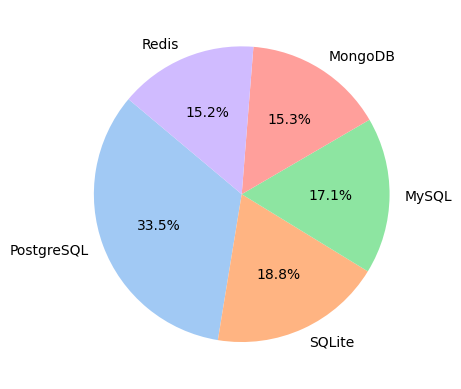

In [85]:
exploded_dbs = df['DatabaseWantToWorkWith'].str.split(';').explode()
top5_dbs = exploded_dbs.value_counts().sort_values(ascending=False).head(5)

plt.pie(top5_dbs, labels=top5_dbs.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


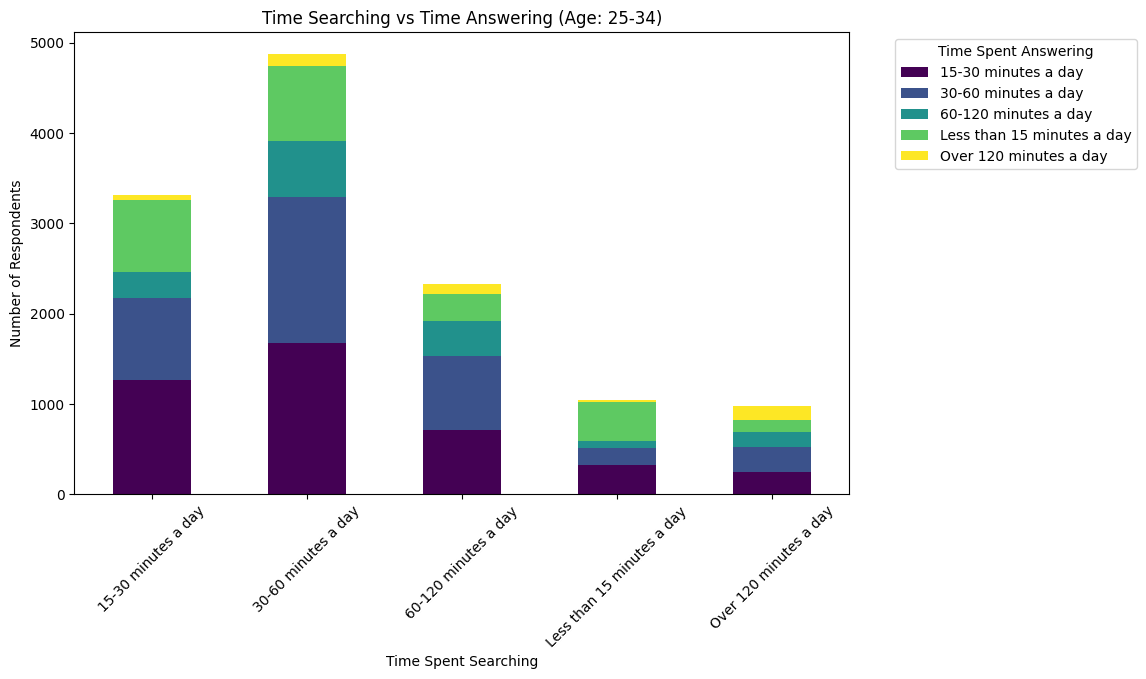

In [92]:
# 1. Filtrujemy dane dla konkretnej grupy wiekowej
# W tym zbiorze 30-35 mieści się zazwyczaj w kategorii '25-34 years old'
df_30_35 = df[df['Age'] == '25-34 years old']

# 2. Tworzymy tabelę przestawną dla obu zmiennych
# To zliczy ile osób o danym 'TimeSearching' ma dany 'TimeAnswering'
chart_data = pd.crosstab(df_30_35['TimeSearching'], df_30_35['TimeAnswering'])

# 3. Rysujemy Stacked Bar Chart
chart_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Time Searching vs Time Answering (Age: 25-34)')
plt.xlabel('Time Spent Searching')
plt.ylabel('Number of Respondents')
plt.legend(title='Time Spent Answering', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


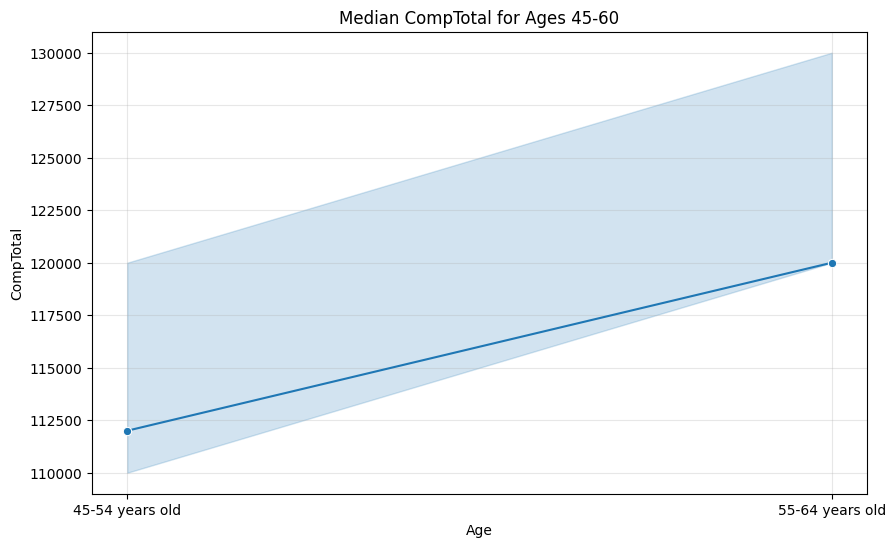

In [105]:
# 1. Wybieramy odpowiednie grupy wiekowe (45-60)
age_filter = ['45-54 years old', '55-64 years old']
df_filtered = df[df['Age'].isin(age_filter)].copy()

# 2. Usuwamy ekstremalne błędy (Outliers) dla CompTotal
# Używamy np. metody IQR lub po prostu odcinamy wartości powyżej pewnego progu
Q1 = df_filtered['CompTotal'].quantile(0.25)
Q3 = df_filtered['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
# Filtrujemy tylko wartości w sensownym zakresie
df_clean = df_filtered[~((df_filtered['CompTotal'] < (Q1 - 1.5 * IQR)) | (df_filtered['CompTotal'] > (Q3 + 1.5 * IQR)))]

# 3. Rysujemy wykres z użyciem mediany jako estymatora
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_clean, x='Age', y='CompTotal', estimator='median', marker='o')

plt.title('Median CompTotal for Ages 45-60')
plt.grid(True, alpha=0.3)
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [108]:
df['MainBranch'].value_counts()

MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64

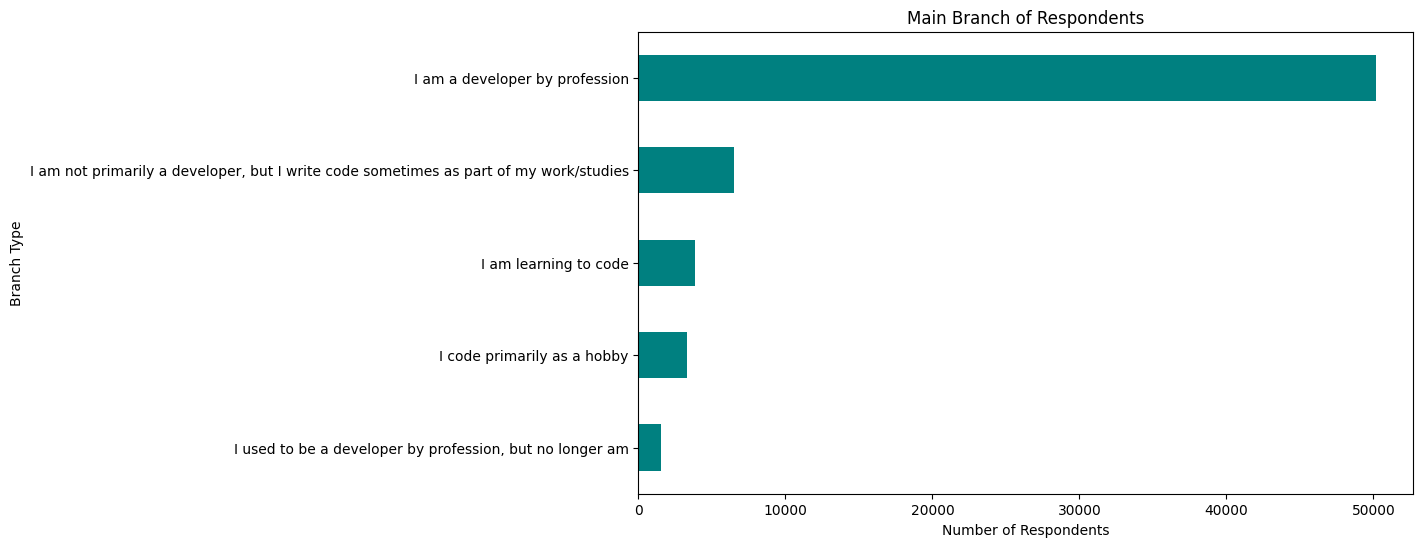

In [ ]:
# 1. Przygotowujemy dane (już to zrobiłeś, ale zapiszmy do zmiennej)
main_branch_counts = df['MainBranch'].value_counts()

# 2. Rysujemy wykres poziomy
plt.figure(figsize=(10, 6))
main_branch_counts.plot(kind='barh', color='teal')

# 3. Dodajemy opisy
plt.title('Main Branch of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Branch Type')

# Odwracamy oś Y, żeby najpopularniejsza kategoria była na górze
plt.gca().invert_yaxis()

plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
